# 4. Diskretni signali in sistemi v frekvenčnem prostoru

Ta interaktivni zvezek obravnava frekvenčno predstavitev signalov in analizo Linearnih Časovno Invariantnih (LČI) sistemov. Temelji na spoznanju, da se vsi zvezni periodični signali lahko predstavijo z vsoto pravilno izbranih sinusnih signalov.

## 4.1 Signal v časovni in frekvenčni domeni
Pri analizi signalov pogosto trčimo ob problem, da so signali manjših amplitud v časovni domeni skriti ali slabo vidni, medtem ko postanejo v frekvenčni domeni (spektru) zelo jasno prepoznavni. 

V spodnjem primeru bomo ustvarili sestavljen zvočni signal (nizek močen ton + visok šibek ton + šum) in ga analizirali v obeh domenah.

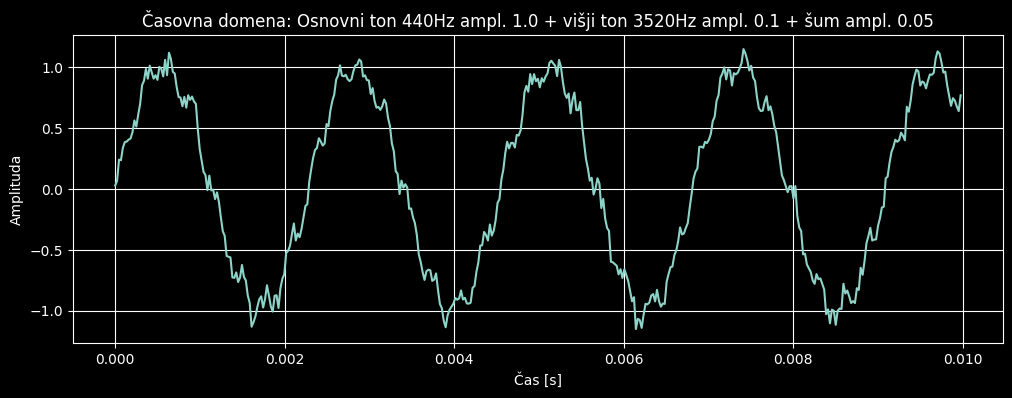

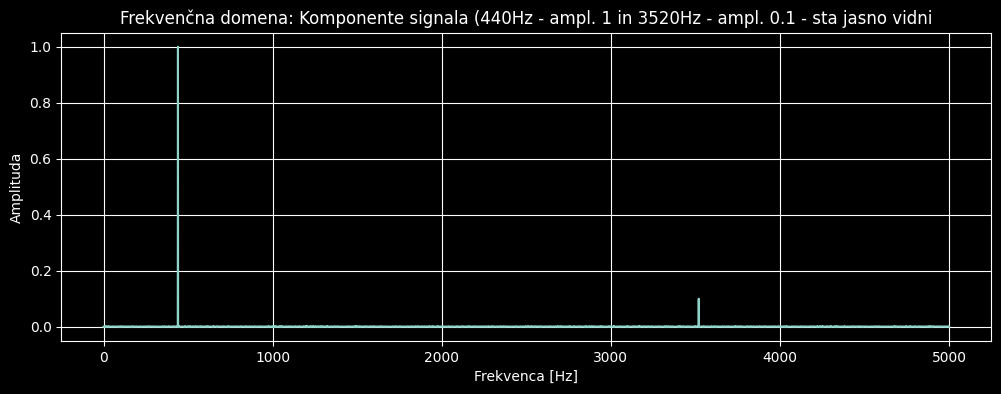

Poslušaj čisti ton 440Hz (brez šuma in visokega tona):


Poslušaj sestavljeni signal (z vključenim šumom in visokim tonom):


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import signal
from IPython.display import Audio

# 1. Parametri signala
fs = 44100  # Frekvenca vzorčenja v Hz (CD kvaliteta)
t = np.linspace(0, 1.0, fs, endpoint=False)  # Časovni vektor (1 sekunda)

# 2. Sestavljanje signala
f1, A1 = 440.0, 1.0    # Osnovni ton (A4), močna amplituda
f2, A2 = 3520.0, 0.1   # Višji harmonski ton, majhna amplituda
x = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)
x_noise = x + np.random.normal(0, 0.05, len(t)) # Dodamo rahel šum

# 3. Časovna domena
plt.figure(figsize=(12, 4))
samples = int(fs * 0.01) # Prikaz prvih 10 milisekund
plt.plot(t[:samples], x_noise[:samples])
plt.title('Časovna domena: Osnovni ton 440Hz ampl. 1.0 + višji ton 3520Hz ampl. 0.1 + šum ampl. 0.05')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# 4. Frekvenčna domena (Amplitudni spekter)
N = len(x_noise)
yf = fft(x_noise)
xf = fftfreq(N, 1/fs)

plt.figure(figsize=(12, 4))
mask = (xf >= 0) & (xf <= 5000) # Gledamo samo do 5 kHz
plt.plot(xf[mask], 2.0/N * np.abs(yf[mask]))
plt.title('Frekvenčna domena: Komponente signala (440Hz - ampl. 1 in 3520Hz - ampl. 0.1 - sta jasno vidni')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# 5. Poslušanje osnovnga tona 440Hz
print("Poslušaj čisti ton 440Hz (brez šuma in visokega tona):")
display(Audio(A1 * np.sin(2 * np.pi * f1 * t), rate=fs))

# 6. Poslušanje sestavljenega signala
print("Poslušaj sestavljeni signal (z vključenim šumom in visokim tonom):")
display(Audio(x_noise, rate=fs))

## 4.3 Frekvenčni odziv LČI sistema
Frekvenčni odziv sistema opredeljuje kompleksna funkcija $H(e^{j\omega})$, ki nam pove, kaj se zgodi z vsako posamezno frekvenčno komponento pri prehodu skozi sistem. 
Delimo ga na:
* **Amplitudni odziv** ($|H(e^{j\omega})|$): določa spremembo amplitude lastne funkcije.
* **Fazni odziv** ($\angle H(e^{j\omega})$): določa spremembo faze oz. zakasnitev komponente.

Ustvarimo preprost LČI sistem (nizkoprepustni drseči povprečevalnik - Moving Average filter) in vizualizirajmo njegov odziv.

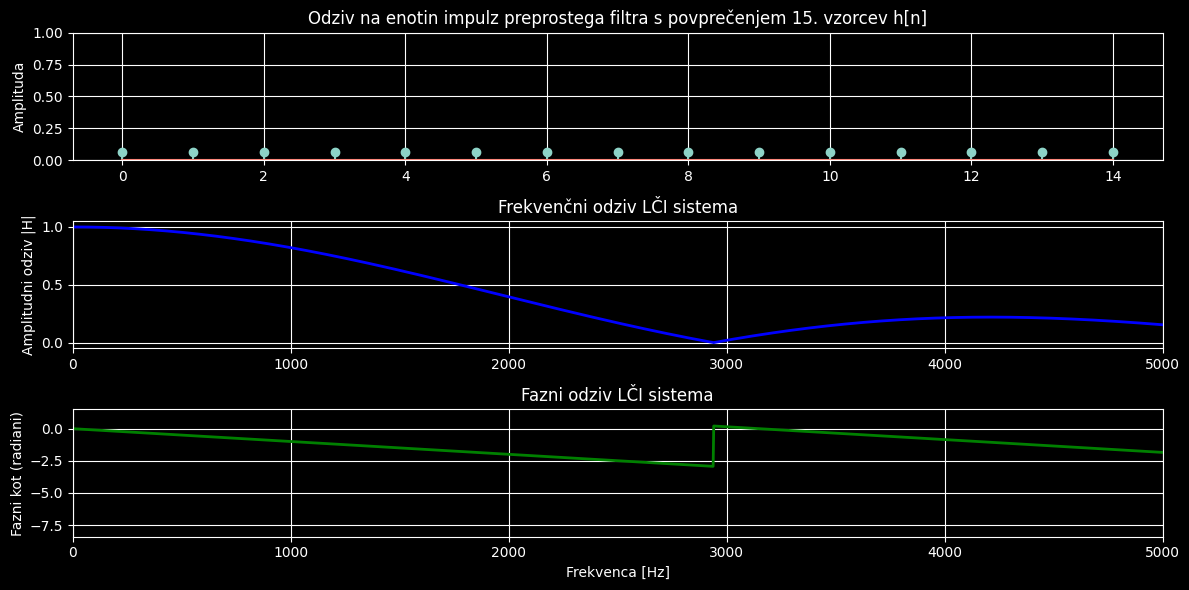

In [5]:
# Definiramo koeficiente za FIR nizkoprepustni filter
N_filter = 15 # Red filtra
h = np.ones(N_filter) / N_filter # Impulzni odziv sistema

# Izračun frekvenčnega odziva sistema H(e^jw)
w, H = signal.freqz(h, worN=8000)
frekvence_Hz = (w / np.pi) * (fs / 2)

plt.figure(figsize=(12, 6))

#Odziv na enotin impulz
#axs[0].stem(n, delta)
#axs[0].set_title('Enotin impulz δ[n]')

plt.subplot(3, 1, 1)
n = np.arange(0, N_filter)
plt.stem(n, h)
plt.title('Odziv na enotin impulz preprostega filtra s povprečenjem 15. vzorcev h[n]')
plt.ylabel('Amplituda')
plt.ylim(0, 1)
plt.grid(True)

# Amplitudni odziv
plt.subplot(3, 1, 2)
plt.plot(frekvence_Hz, np.abs(H), 'b', linewidth=2)
plt.title('Frekvenčni odziv LČI sistema')
plt.ylabel('Amplitudni odziv |H|')
plt.grid(True)
plt.xlim(0, 5000)

# Fazni odziv
plt.subplot(3, 1, 3)
angles = np.unwrap(np.angle(H))
plt.plot(frekvence_Hz, angles, 'g', linewidth=2)
plt.title('Fazni odziv LČI sistema')
plt.ylabel('Fazni kot (radiani)')
plt.xlabel('Frekvenca [Hz]')
plt.grid(True)
plt.xlim(0, 5000)

plt.tight_layout()
plt.show()

## Vpliv sistema na sestavljen signal
Vpliv sistema na sestavljeni signal je preprosto vsota odzivov na njegove posamezne komponente. Zgornji nizkoprepustni filter bomo sedaj uporabili na našem začetnem zvočnem signalu. Filter bo utišal visoke frekvence (šum in ton 3520 Hz), faza pa bo vplivala na zakasnitev preostalega signala v času.

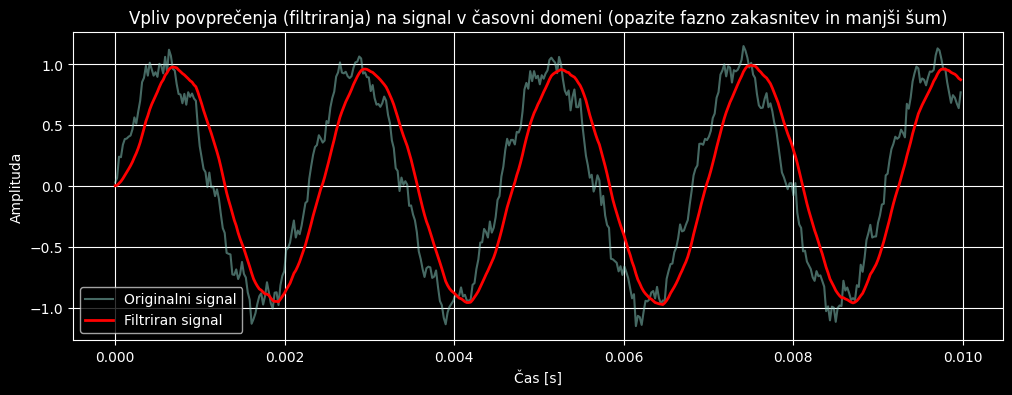

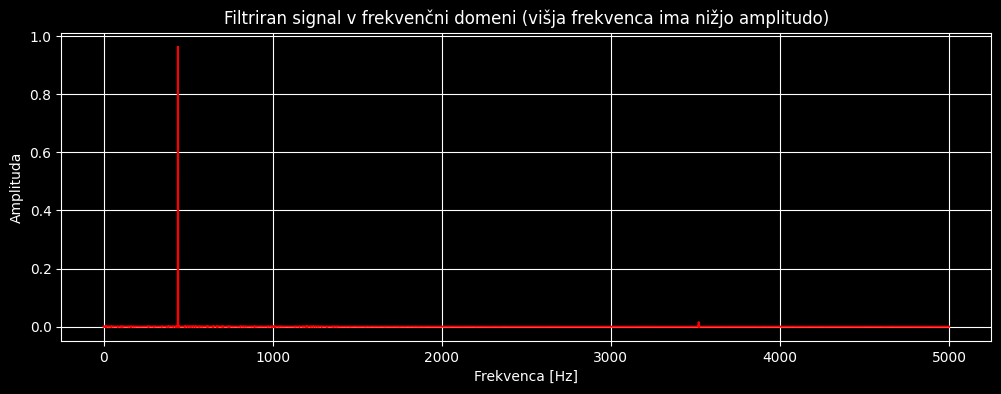

Poslušaj filtrirani signal (zveneti bi moral bolj čisto, z manj šuma in visokega tona):


In [3]:
# Uporaba filtra na signalu (konvolucija v časovni domeni)
y = signal.lfilter(h, 1.0, x_noise)

# Prikaz v časovni domeni (Zakasnitev in glajenje)
plt.figure(figsize=(12, 4))
plt.plot(t[:samples], x_noise[:samples], label='Originalni signal', alpha=0.5)
plt.plot(t[:samples], y[:samples], label='Filtriran signal', linewidth=2, color='red')
plt.title('Vpliv povprečenja (filtriranja) na signal v časovni domeni (opazite fazno zakasnitev in manjši šum)')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.legend()
plt.grid(True)
plt.show()

# Prikaz v frekvenčni domeni
yf_filtered = fft(y)
plt.figure(figsize=(12, 4))
plt.plot(xf[mask], 2.0/N * np.abs(yf_filtered[mask]), color='red')
plt.title('Filtriran signal v frekvenčni domeni (višja frekvenca ima nižjo amplitudo)')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# Poslušanje filtriranega signala
print("Poslušaj filtrirani signal (zveneti bi moral bolj čisto, z manj šuma in visokega tona):")
display(Audio(y, rate=fs))

## Zveza med FT in Z-transformacijo
Za celovito razumevanje sistema je ključno poznavanje Z-transformacije. Fourierova transformacija je pravzaprav le poseben primer Z-transformacije, ki je ovrednotena izključno na enotski krožnici v Z-ravnini, torej pri $|z|=1$. Spodnji graf prikazuje položaj polov in ničel našega filtra.

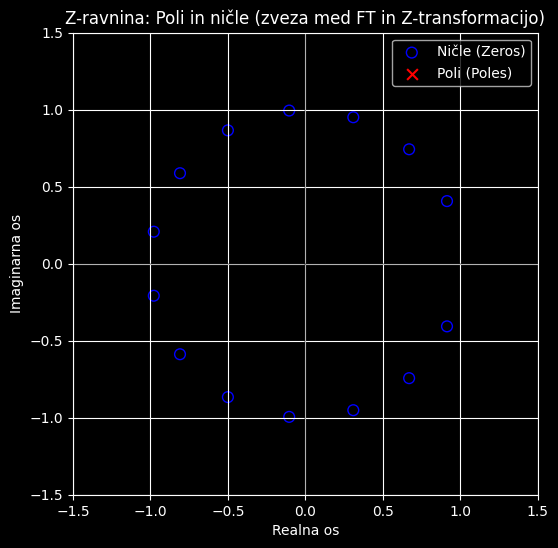

In [4]:
# Izračun polov in ničel prenosne funkcije H(z)
z, p, k = signal.tf2zpk(h, [1.0])

plt.figure(figsize=(6, 6))
# Risanje enotske krožnice
unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(unit_circle)

# Risanje ničel (zeros) in polov (poles)
plt.scatter(np.real(z), np.imag(z), s=60, marker='o', facecolors='none', edgecolors='b', label='Ničle (Zeros)')
plt.scatter(np.real(p), np.imag(p), s=60, marker='x', color='r', label='Poli (Poles)')

plt.title('Z-ravnina: Poli in ničle (zveza med FT in Z-transformacijo)')
plt.xlabel('Realna os')
plt.ylabel('Imaginarna os')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()